
PROBLEM STATEMENT
Hotel booking cancellations cause significant revenue loss and planning difficulties for hotels.
Predicting whether a booking will be canceled helps hotel management optimize resource allocation,
reduce revenue losses, and improve customer service. Using machine learning techniques,
we can analyze historical booking data and predict future cancellations accurately.


OBJECTIVE
The objective of this project is to build an efficient machine learning model
that predicts whether a hotel booking will be canceled based on historical
booking data and customer information.

Dataset Loaded Successfully
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               20

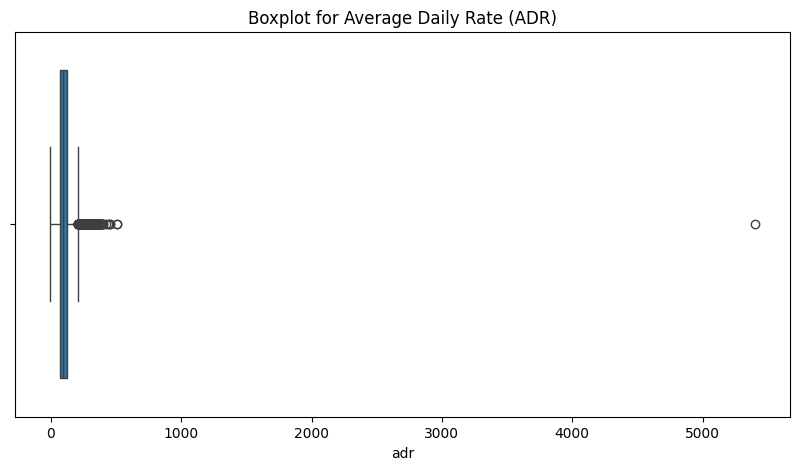

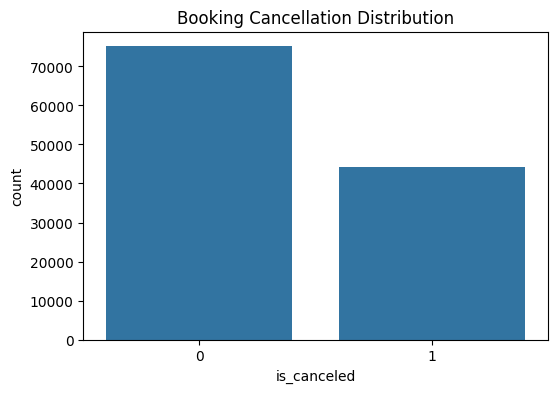

Insight: Majority of bookings are not cancelled compared to cancelled bookings.


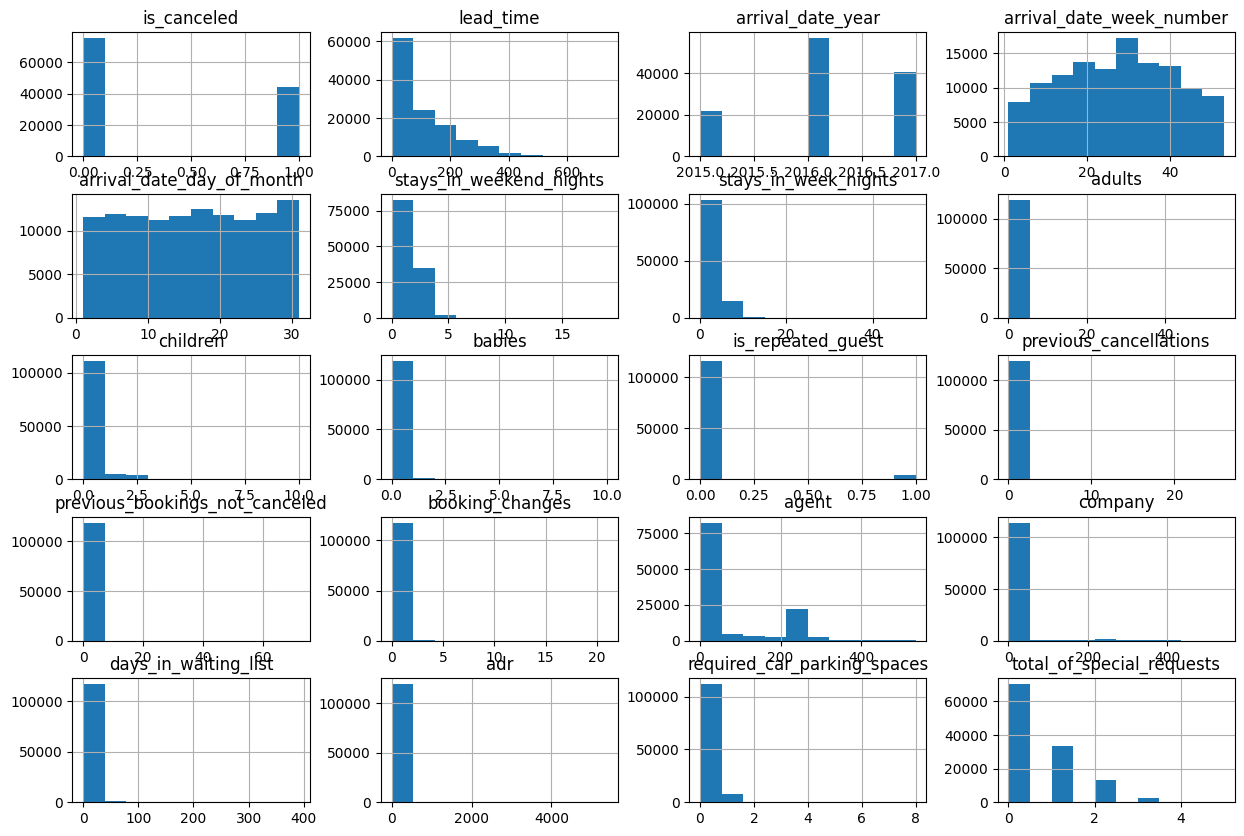

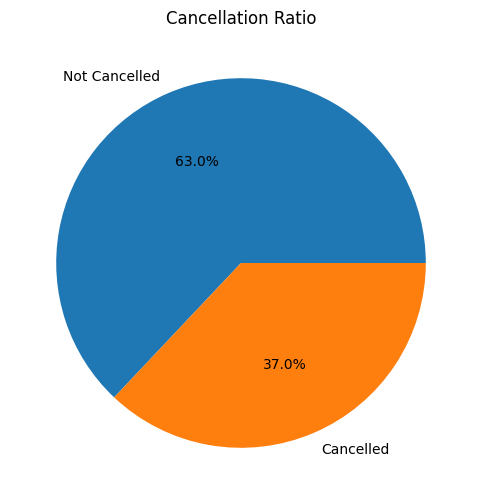

Insight: The pie chart shows that a larger percentage of bookings are completed while a smaller portion are cancelled.


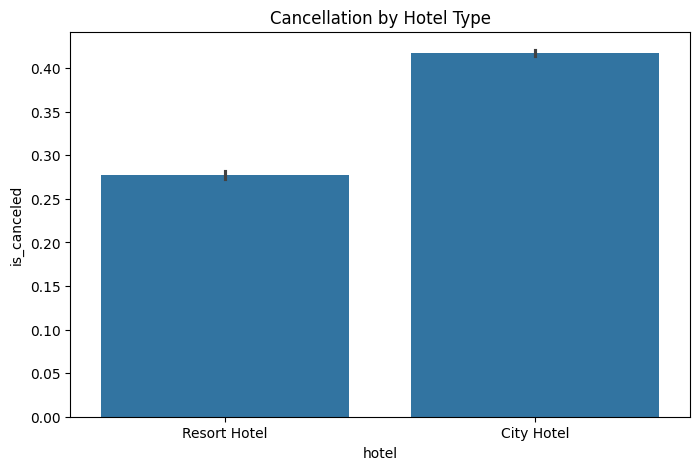

Insight: City hotels generally have a higher cancellation rate compared to resort hotels.


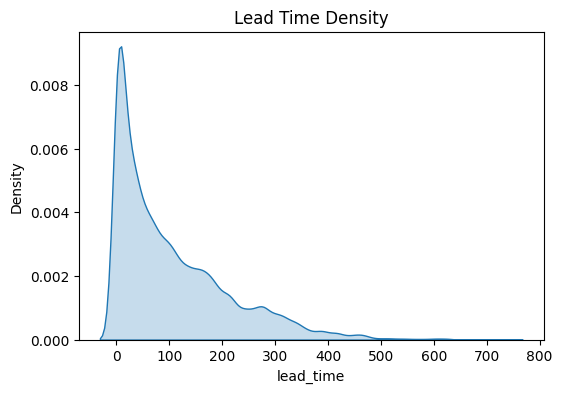

Insight: Bookings made with longer lead times tend to have higher chances of cancellation.


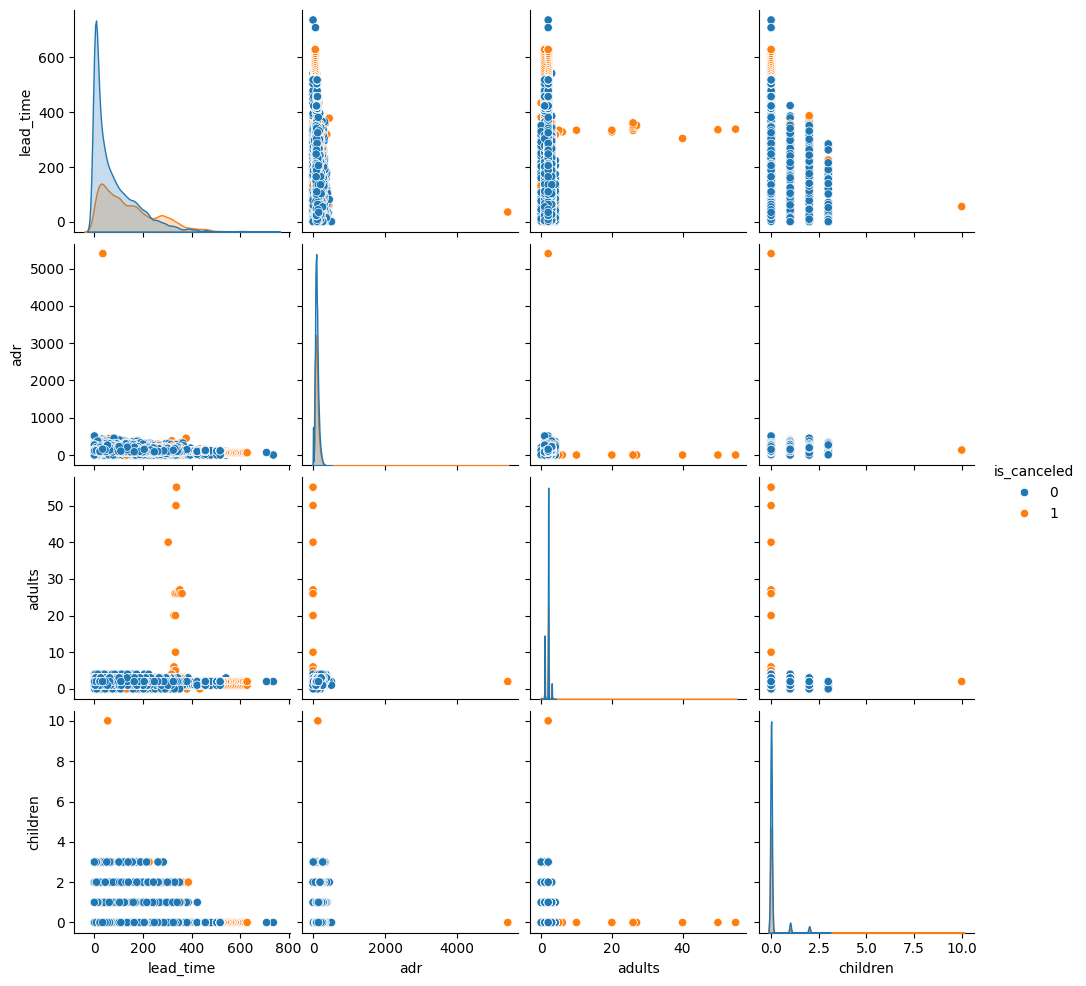

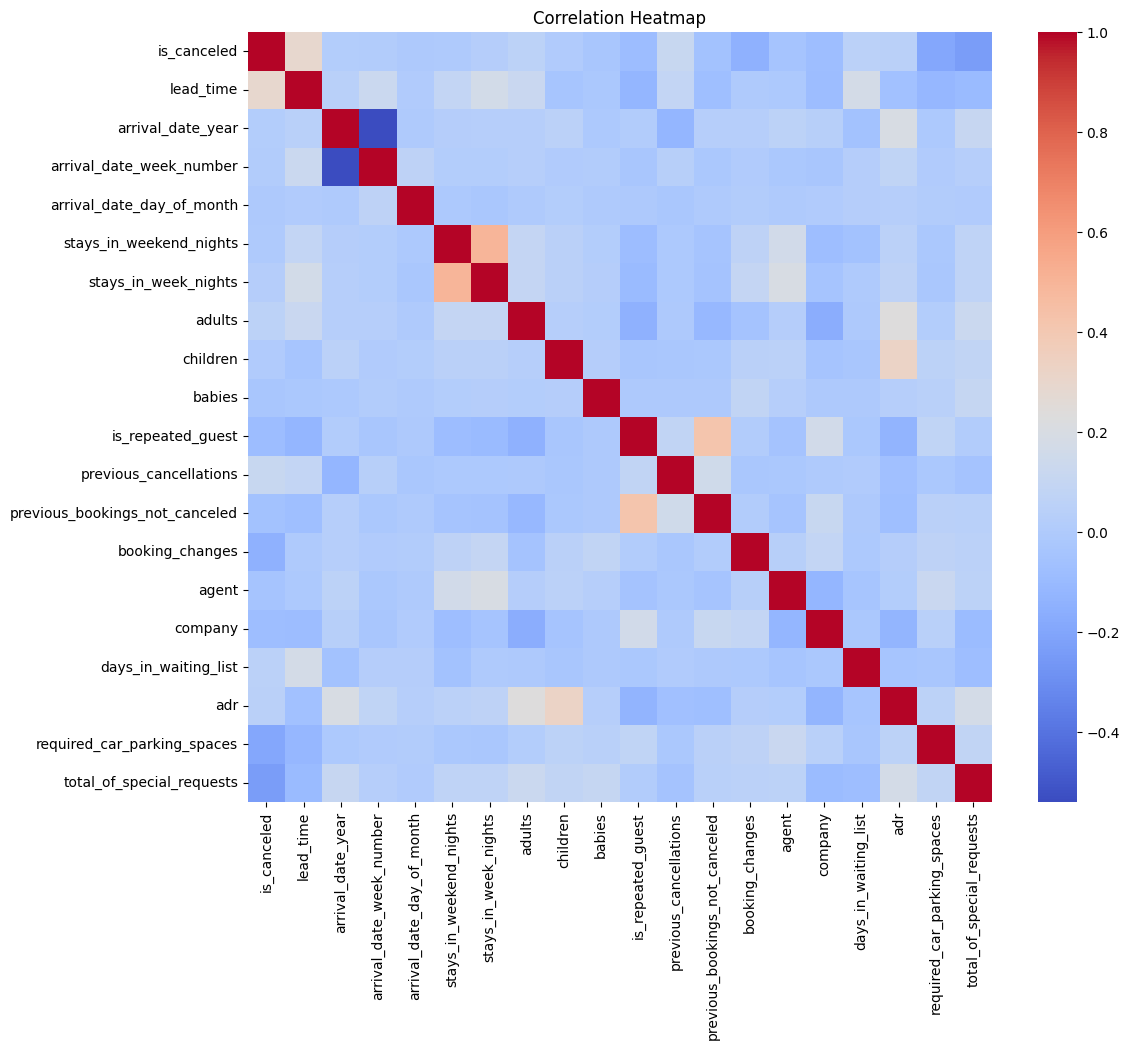

Insight: The heatmap shows relationships between numerical variables and helps identify features influencing cancellations.
Categorical features encoded
Training Size: (95512, 29)
Testing Size: (23878, 29)

Logistic Regression
Accuracy: 0.7945389061060391
              precision    recall  f1-score   support

           0       0.79      0.92      0.85     14907
           1       0.81      0.59      0.68      8971

    accuracy                           0.79     23878
   macro avg       0.80      0.75      0.77     23878
weighted avg       0.80      0.79      0.79     23878


Decision Tree
Accuracy: 0.8555574168690845
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     14907
           1       0.80      0.81      0.81      8971

    accuracy                           0.86     23878
   macro avg       0.85      0.85      0.85     23878
weighted avg       0.86      0.86      0.86     23878


Random Forest
Accuracy: 0.8981908032498535
  

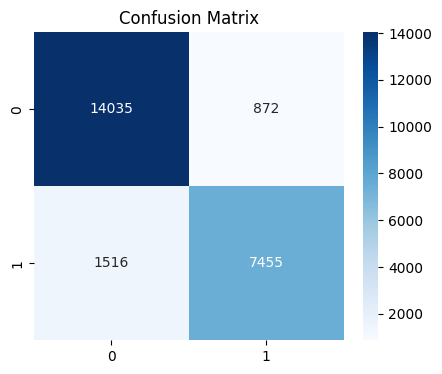

ROC AUC Score: 0.8862575134862267
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Model saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


CONCLUSION
The machine learning model successfully predicts hotel booking cancellations.
Among the tested algorithms, Random Forest performed best.
This model can help hotels forecast cancellations and improve booking strategies.


REFERENCES
1. Kaggle - Hotel Booking Demand Dataset
2. Scikit-learn Documentation
3. Pandas Documentation
4. Seaborn Visualization Library



In [9]:
# MACHINE LEARNING PROJECT
# Hotel Booking Cancellation Prediction Using Machine Learning
# Name: Diana Thomas
# Organization: Entri Elevate

# ===============================
# 1. INSTALL LIBRARIES
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

# ===============================
# 2. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle

from google.colab import files

# 1. OVERVIEW OF PROBLEM STATEMENT

print("""
PROBLEM STATEMENT
Hotel booking cancellations cause significant revenue loss and planning difficulties for hotels.
Predicting whether a booking will be canceled helps hotel management optimize resource allocation,
reduce revenue losses, and improve customer service. Using machine learning techniques,
we can analyze historical booking data and predict future cancellations accurately.
""")

# 2. OBJECTIVE

print("""
OBJECTIVE
The objective of this project is to build an efficient machine learning model
that predicts whether a hotel booking will be canceled based on historical
booking data and customer information.
""")

# 3. LOAD DATASET

df = pd.read_csv("hotel-bookings.csv")

print("Dataset Loaded Successfully")
print(df.head())
print("Dataset Source: Kaggle - Hotel Booking Demand Dataset")
print("Target Variable: is_canceled")

# DATA DESCRIPTION

print("\nDATASET INFORMATION")
print(df.info())

print("\nDATASET SHAPE")
print(df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# 4. DATA PREPROCESSING & CLEANING

# Remove date column
df.drop(['reservation_status_date','reservation_status'], axis=1, inplace=True)
# Handle missing values

df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# Ensure no missing values remain
df = df.dropna()

print("Remaining missing values:")
print(df.isnull().sum())

# OUTLIER DETECTION

plt.figure(figsize=(10,5))
sns.boxplot(x=df['adr'])
plt.title("Boxplot for Average Daily Rate (ADR)")
plt.show()


# 5. EXPLORATORY DATA ANALYSIS (EDA)

# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=df)
plt.title("Booking Cancellation Distribution")
plt.show()
print("Insight: Majority of bookings are not cancelled compared to cancelled bookings.")

# Histogram
df.hist(figsize=(15,10))
plt.show()

# Pie Chart
cancel_counts = df['is_canceled'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(cancel_counts, labels=['Not Cancelled','Cancelled'], autopct='%1.1f%%')
plt.title("Cancellation Ratio")
plt.show()
print("Insight: The pie chart shows that a larger percentage of bookings are completed while a smaller portion are cancelled.")

# Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(x='hotel', y='is_canceled', data=df)
plt.title("Cancellation by Hotel Type")
plt.show()
print("Insight: City hotels generally have a higher cancellation rate compared to resort hotels.")

# KDE Plot
plt.figure(figsize=(6,4))
sns.kdeplot(df['lead_time'], fill=True)
plt.title("Lead Time Density")
plt.show()
print("Insight: Bookings made with longer lead times tend to have higher chances of cancellation.")

# Pair Plot
sns.pairplot(df[['lead_time','adr','adults','children','is_canceled']], hue='is_canceled')
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
print("Insight: The heatmap shows relationships between numerical variables and helps identify features influencing cancellations.")


# 6. FEATURE ENGINEERING
# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("Categorical features encoded")


# 7. FEATURE SCALING


X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 8. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)


# 9. MODEL BUILDING

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

model_results = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    model_results[name] = accuracy

    print("\n=======================")
    print(name)
    print("Accuracy:", accuracy)
    print(classification_report(y_test, preds))


# CONFUSION MATRIX


rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_pred))


# 10. HYPERPARAMETER TUNING


param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


# 12. MODEL DEPLOYMENT (SAVE MODEL)


with open("hotel_booking_model.pkl","wb") as file:
    pickle.dump(best_model,file)

print("Model saved successfully")

# Download model
files.download("hotel_booking_model.pkl")

# 13. CONCLUSION

print("""
CONCLUSION
The machine learning model successfully predicts hotel booking cancellations.
Among the tested algorithms, Random Forest performed best.
This model can help hotels forecast cancellations and improve booking strategies.
""")

# 4. REFERENCES

print("""
REFERENCES
1. Kaggle - Hotel Booking Demand Dataset
2. Scikit-learn Documentation
3. Pandas Documentation
4. Seaborn Visualization Library
""")